# **Image Classification with a MLP on CIFAR-10**

In [ ]:
import keras

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
y_train, y_test = y_train.ravel(), y_test.ravel()

In [4]:
# Replace labels with their corresponding class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

y_train = [class_names[label] for label in y_train]
y_test = [class_names[label] for label in y_test]


In [5]:
# Flatten de cada imagen, conservando el eje de muestras
X_train_flat = X_train.reshape(len(X_train), -1) #
X_test_flat = X_test.reshape(len(X_test), -1)

# Some alternative ways to flatten the images (commented out)
# X_train_flat = np.array([img.flatten() for img in X_train])
# X_test_flat = np.array([img.flatten() for img in X_test])

In [6]:
# Fit a MLP classifier to the training data
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=20, random_state=42)
mlp.fit(X_train_flat, y_train)

/Users/eugenio/Documents/ComputerVision/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(max_iter=20, random_state=42)

In [7]:
# Show the accuracy with the score method
accuracy = mlp.score(X_test_flat, y_test)
accuracy

0.4023

Text(95.72222222222221, 0.5, 'True')

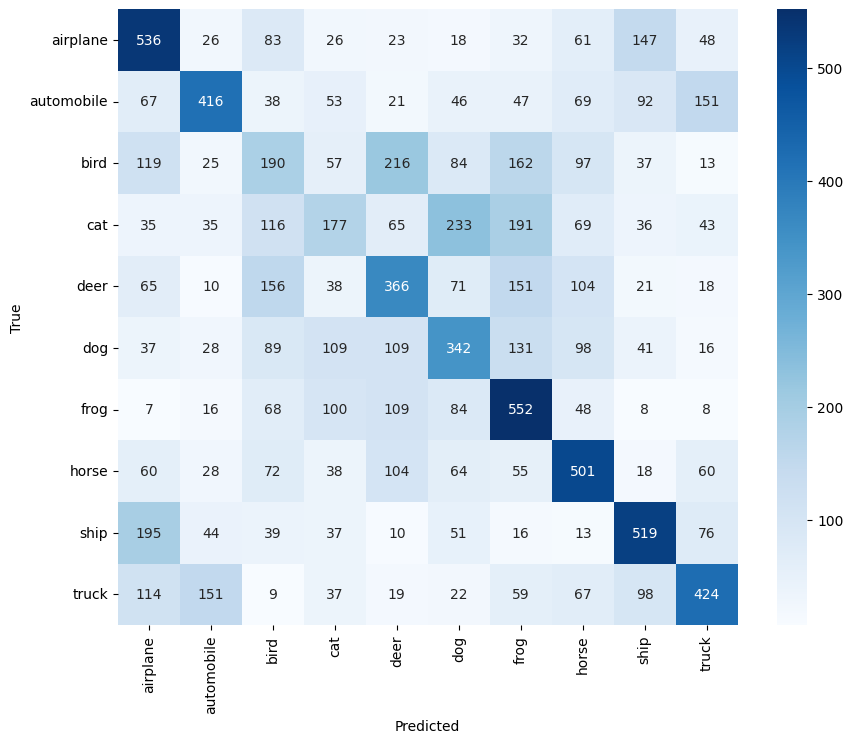

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Plot the heatmap of the confusion matrix
import seaborn as sns
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, mlp.predict(X_test_flat), labels=class_names) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')

In [14]:
# Shoe the classification report
report = classification_report(y_test, mlp.predict(X_test_flat), target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.43      0.54      0.48      1000
  automobile       0.53      0.42      0.47      1000
        bird       0.22      0.19      0.20      1000
         cat       0.26      0.18      0.21      1000
        deer       0.35      0.37      0.36      1000
         dog       0.34      0.34      0.34      1000
        frog       0.40      0.55      0.46      1000
       horse       0.44      0.50      0.47      1000
        ship       0.51      0.52      0.51      1000
       truck       0.49      0.42      0.46      1000

    accuracy                           0.40     10000
   macro avg       0.40      0.40      0.40     10000
weighted avg       0.40      0.40      0.40     10000

